# 06_power_simulation.ipynb

> Pre-experiment sample size simulation
> Uses pilot variance structure to determine whether the planned design can
> estimate the repeat baseline and the additional instability (delta) with
> adequate precision. Runs before the full corpus is generated so that case
> counts and repetition depth can still be revised.

Pilot records: 360
Direction error rate from validation: 0.0000
  n_case_conditions: 120
  mean_claims_per_explanation: 4.7528
  feature_distance_mean: 0.0864
  feature_distance_sd: 0.1752
  direction_distance_mean: 0.0058
  direction_distance_sd: 0.0347
Saved: tab19_pilot_variance_structure.csv
Saved: tab20_simulation_scenarios.csv


,Scenario,base_mean,base_sd,case_sd
0,optimistic,0.0518,0.1226,0.0876
1,pilot,0.0864,0.1752,0.1401
2,pessimistic,0.1209,0.2277,0.1927


Saved: tab21_baseline_precision.csv
Planned design under the pilot scenario:
Scenario  N cases  N repeats  CI halfwidth  Target met
   pilot       60          3        0.0322        True
   pilot       60         20        0.0260        True
   pilot      300          3        0.0147        True
   pilot      300         20        0.0116        True
Saved: tab22_delta_power.csv

Power to detect the target delta under the pilot scenario:
Scenario  N cases  True delta  Mean estimate    Bias  CI halfwidth  Detection rate
   pilot      100         0.1         0.0850 -0.0150        0.0395            0.98
   pilot      300         0.1         0.0835 -0.0165        0.0226            1.00
Saved: tab23_false_positive_rate.csv

False positive rate (delta = 0):
   Scenario  N cases  False positive rate
 optimistic      100                 0.03
 optimistic      300                 0.05
      pilot      100                 0.04
      pilot      300                 0.02
pessimistic      100         

,Scenario,Min cases for power,Min repeats for baseline (60 cases),Planned cases,Planned repeats (deep)
0,optimistic,100,3,300,20
1,pilot,100,3,300,20
2,pessimistic,100,3,300,20


Saved: fig16_baseline_precision.png / fig16_baseline_precision.pdf


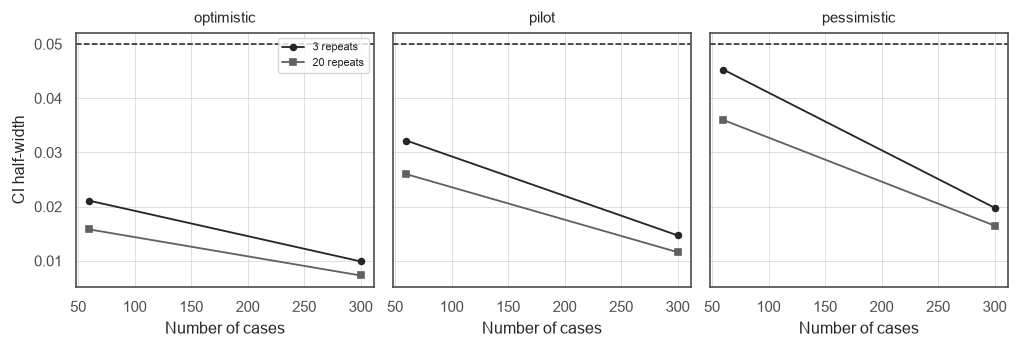

Saved: fig17_delta_power_curves.png / fig17_delta_power_curves.pdf


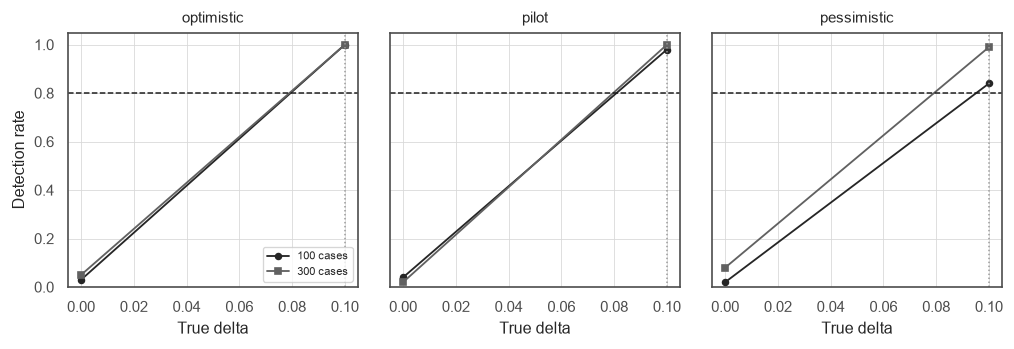

Saved: fig18_estimator_calibration.png / fig18_estimator_calibration.pdf


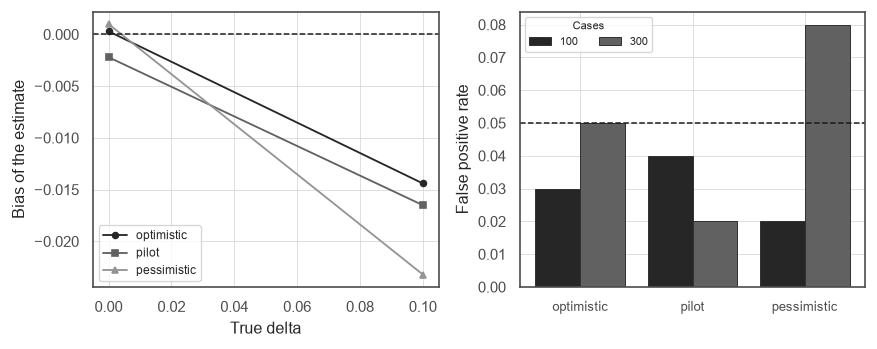

Saved: fig19_case_level_delta_distribution.png / fig19_case_level_delta_distribution.pdf


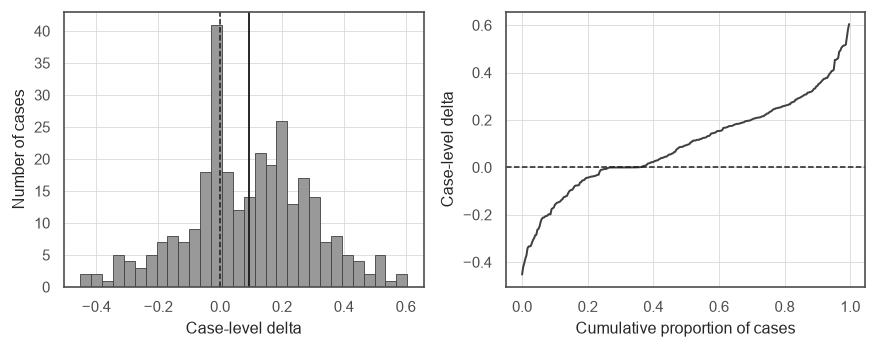

Simulated case-level delta: mean 0.0937, median 0.0929, IQR [-0.0072, 0.2276]
Share of cases with delta above 0.20: 0.300
Planned design retained without revision.
Saved: design_recommendation.json
Saved: tab26_generation_budget.csv


,Block,Purpose,N
0,A,Model / XAI change,5400
1,A',Domain control,5400
2,B,LLM / prompt change,10800
3,C,Bridge comparison,4800
4,D,"Deep repeatability, tau = 1.0",3600
5,D-0,"Deep repeatability, tau = 0",3600
6,Total,,33600


Saved: logs/06_run_20260915.json
Outputs:
  results\tables\tab19_pilot_variance_structure.csv
  results\tables\tab20_simulation_scenarios.csv
  results\tables\tab21_baseline_precision.csv
  results\tables\tab22_delta_power.csv
  results\tables\tab23_false_positive_rate.csv
  results\tables\tab24_design_verdict.csv
  results\tables\tab25_minimum_requirements.csv
  results\tables\tab26_generation_budget.csv
  results\figures\fig16_baseline_precision.pdf
  results\figures\fig16_baseline_precision.png
  results\figures\fig17_delta_power_curves.pdf
  results\figures\fig17_delta_power_curves.png
  results\figures\fig18_estimator_calibration.pdf
  results\figures\fig18_estimator_calibration.png
  results\figures\fig19_case_level_delta_distribution.pdf
  results\figures\fig19_case_level_delta_distribution.png

Design summary
--------------
Cases (main blocks)     300
Repeats (main blocks)   3
Cases (deep blocks)     60
Repeats (deep blocks)   20
Total generations       33,600

Design adequate 

In [1]:
# ============================================================================
# 06_power_simulation.ipynb
# Pre-experiment sample size simulation
# Uses pilot variance structure to determine whether the planned design can
# estimate the repeat baseline and the additional instability (delta) with
# adequate precision. Runs before the full corpus is generated so that case
# counts and repetition depth can still be revised.
# ============================================================================


# [Cell 1] Imports and global configuration
import json
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SEED = 42
rng_global = np.random.default_rng(SEED)

ROOT = Path("..")
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"
LOG_DIR = ROOT / "logs"

for d in [DATA_DIR, FIG_DIR, TAB_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# [Cell 2] Plotting style: grayscale, publication settings
sns.set_theme(style="whitegrid", context="paper")
sns.set_palette(sns.color_palette("gray", n_colors=8))

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.5,
    "axes.edgecolor": "0.3",
    "axes.labelcolor": "0.15",
    "text.color": "0.15",
    "xtick.color": "0.3",
    "ytick.color": "0.3",
    "image.cmap": "gray",
    "savefig.bbox": "tight",
    "savefig.transparent": False,
})


def save_fig(fig, name):
    """Save a figure as both PNG and PDF at 600 dpi. No caption is added."""
    for ext in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")
    print(f"Saved: {name}.png / {name}.pdf")


def save_table(df, name, index=False):
    """Save a table as CSV under results/tables."""
    df.to_csv(TAB_DIR / f"{name}.csv", index=index, encoding="utf-8-sig")
    print(f"Saved: {name}.csv")


# [Cell 3] Simulation configuration
# Planned design, to be confirmed or revised by this notebook.
PLANNED = {
    "n_cases_main": 300,      # Blocks A, A', B
    "n_repeats_main": 3,      # repetitions per condition in the main blocks
    "n_cases_deep": 60,       # Blocks D, D-0
    "n_repeats_deep": 20,     # repetitions in the deep repeatability blocks
    "top_k": 5,
}

N_SIM = 2000                  # simulation replicates per scenario
BOOTSTRAP_B = 1000            # cluster bootstrap draws inside each replicate
CI_LEVEL = 0.95

# Precision targets. These are the criteria by which the design is judged.
TARGETS = {
    "baseline_ci_halfwidth": 0.05,   # repeat baseline estimated to within +/- 0.05
    "delta_ci_halfwidth": 0.05,      # each delta estimated to within +/- 0.05
    "delta_detect": 0.10,            # smallest delta the design should detect
    "power": 0.80,
}


# [Cell 4] Load pilot data to anchor the simulation
# The simulation is only credible if its variance structure comes from observed
# pilot behaviour rather than from arbitrary assumptions.
with open(DATA_DIR / "pilot_extractions.json", encoding="utf-8") as f:
    extractions = json.load(f)

with open(DATA_DIR / "validation_summary.json", encoding="utf-8") as f:
    validation = json.load(f)

print(f"Pilot records: {len(extractions):,}")
print(f"Direction error rate from validation: "
      f"{validation['measurement_error']['direction_error_rate']:.4f}")


# [Cell 5] Distance functions
# Identical definitions to those used in 08_content_distance, so that the
# simulated quantities match the quantities that will actually be estimated.
def claim_sets(claims):
    """Return the feature set and the feature-to-direction map for a claim list."""
    feats, dirs = set(), {}
    for c in claims:
        f = c.get("feature")
        if not f or f == "OUT_OF_LIST":
            continue
        feats.add(f)
        d = c.get("direction")
        dirs[f] = d if d in ("increases", "decreases") else None
    return feats, dirs


def feature_distance(a, b):
    """One minus the Jaccard index of the two feature sets."""
    fa, _ = claim_sets(a)
    fb, _ = claim_sets(b)
    union = fa | fb
    if not union:
        return np.nan
    return 1.0 - len(fa & fb) / len(union)


def direction_distance(a, b):
    """Share of commonly mentioned features whose stated direction differs."""
    fa, da = claim_sets(a)
    fb, db = claim_sets(b)
    common = [f for f in fa & fb if da.get(f) and db.get(f)]
    if not common:
        return np.nan
    return 1.0 - float(np.mean([da[f] == db[f] for f in common]))


# [Cell 6] Estimate the pilot variance structure
# The pilot generated one narrative per (block, prompt), so within-condition
# repetition is not directly observable. What the pilot does provide is the
# between-prompt spread and the per-case dispersion, which together give a
# defensible starting point for the simulated parameters.
def pilot_structure(extraction_records):
    """Summarise observed claim counts and between-prompt distances."""
    by_case = {}
    for r in extraction_records:
        key = (r["domain"], r["model"], r["xai"], r["case_id"])
        by_case.setdefault(key, {})[r["prompt"]] = r["claims"]

    feat_d, dir_d, n_claims = [], [], []
    for key, prompts in by_case.items():
        for c in prompts.values():
            n_claims.append(len(claim_sets(c)[0]))
        for a, b in combinations(prompts.values(), 2):
            fd, dd = feature_distance(a, b), direction_distance(a, b)
            if not np.isnan(fd):
                feat_d.append(fd)
            if not np.isnan(dd):
                dir_d.append(dd)

    return {
        "n_case_conditions": len(by_case),
        "mean_claims_per_explanation": float(np.mean(n_claims)),
        "feature_distance_mean": float(np.mean(feat_d)),
        "feature_distance_sd": float(np.std(feat_d, ddof=1)),
        "direction_distance_mean": float(np.mean(dir_d)),
        "direction_distance_sd": float(np.std(dir_d, ddof=1)),
    }


structure = pilot_structure(extractions)
for k, v in structure.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

structure_df = pd.DataFrame([structure])
save_table(structure_df, "tab19_pilot_variance_structure")


# [Cell 7] Data-generating model for the simulation
# Distances are bounded in [0, 1], so a beta distribution is used rather than a
# normal. Each case carries its own latent mean distance, which reproduces the
# clustering that the cluster bootstrap is designed to handle.
def beta_params(mean, sd):
    """Convert a mean and standard deviation into beta shape parameters."""
    mean = float(np.clip(mean, 1e-3, 1 - 1e-3))
    max_sd = np.sqrt(mean * (1 - mean)) * 0.99
    sd = float(np.clip(sd, 1e-4, max_sd))
    nu = mean * (1 - mean) / sd**2 - 1
    nu = max(nu, 1e-3)
    return mean * nu, (1 - mean) * nu


def simulate_block(n_cases, n_repeats, base_mean, base_sd,
                   case_sd, delta=0.0, rng=None):
    """
    Simulate pairwise distances for one condition.

    n_cases     number of cases
    n_repeats   generations per case within the condition
    base_mean   population mean distance for the repeat baseline
    base_sd     within-case dispersion of individual pair distances
    case_sd     between-case dispersion of latent case means
    delta       shift added to the case means for a changed condition
    """
    rng = rng or np.random.default_rng()

    # Latent case means, shifted by delta for changed conditions
    case_means = np.clip(
        rng.normal(base_mean + delta, case_sd, size=n_cases), 0.005, 0.995
    )

    n_pairs = n_repeats * (n_repeats - 1) // 2
    rows = []
    for case_id, mu in enumerate(case_means):
        a, b = beta_params(mu, base_sd)
        draws = rng.beta(a, b, size=n_pairs)
        rows.append(pd.DataFrame({"case_id": case_id, "distance": draws}))
    return pd.concat(rows, ignore_index=True)


# [Cell 8] Cluster bootstrap
# Resampling is at the case level, matching the inference procedure specified
# for the main analysis. Pairs within a case are always resampled together.
def cluster_bootstrap_ci(df, value_col="distance", cluster_col="case_id",
                         B=BOOTSTRAP_B, level=CI_LEVEL, rng=None):
    """Percentile confidence interval for the mean, resampling whole clusters."""
    rng = rng or np.random.default_rng()
    clusters = df[cluster_col].unique()
    grouped = {c: g[value_col].values for c, g in df.groupby(cluster_col)}

    stats = np.empty(B)
    for i in range(B):
        picked = rng.choice(clusters, size=len(clusters), replace=True)
        vals = np.concatenate([grouped[c] for c in picked])
        stats[i] = vals.mean()

    alpha = (1 - level) / 2
    return float(np.quantile(stats, alpha)), float(np.quantile(stats, 1 - alpha))


def cluster_bootstrap_delta_ci(df_change, df_base, value_col="distance",
                               cluster_col="case_id", B=BOOTSTRAP_B,
                               level=CI_LEVEL, rng=None):
    """
    Confidence interval for delta, resampling cases jointly across conditions.

    Cases are shared between the changed condition and the baseline, so the same
    resampled case index is applied to both. This preserves the within-case
    pairing that makes delta a case-level contrast rather than a difference of
    two independent means.
    """
    rng = rng or np.random.default_rng()
    clusters = np.intersect1d(df_change[cluster_col].unique(),
                              df_base[cluster_col].unique())
    g_change = {c: g[value_col].values for c, g in df_change.groupby(cluster_col)}
    g_base = {c: g[value_col].values for c, g in df_base.groupby(cluster_col)}

    stats = np.empty(B)
    for i in range(B):
        picked = rng.choice(clusters, size=len(clusters), replace=True)
        # Case-level delta, then averaged across the resampled cases
        deltas = [g_change[c].mean() - g_base[c].mean() for c in picked]
        stats[i] = float(np.mean(deltas))

    alpha = (1 - level) / 2
    return float(np.quantile(stats, alpha)), float(np.quantile(stats, 1 - alpha))


# [Cell 9] Scenario grid
# Three variance scenarios span the plausible range. The optimistic and
# pessimistic scenarios bracket the pilot estimate so that the design is not
# judged on a single point assumption.
SCENARIOS = {
    "optimistic": {
        "base_mean": structure["feature_distance_mean"] * 0.6,
        "base_sd": structure["feature_distance_sd"] * 0.7,
        "case_sd": structure["feature_distance_sd"] * 0.5,
    },
    "pilot": {
        "base_mean": structure["feature_distance_mean"],
        "base_sd": structure["feature_distance_sd"],
        "case_sd": structure["feature_distance_sd"] * 0.8,
    },
    "pessimistic": {
        "base_mean": min(structure["feature_distance_mean"] * 1.4, 0.60),
        "base_sd": structure["feature_distance_sd"] * 1.3,
        "case_sd": structure["feature_distance_sd"] * 1.1,
    },
}

scenario_df = pd.DataFrame(SCENARIOS).T.round(4).reset_index().rename(
    columns={"index": "Scenario"}
)
save_table(scenario_df, "tab20_simulation_scenarios")
display(scenario_df)


# [Cell 10] Simulation: precision of the repeat baseline
# Question: with the planned number of cases and repetitions, how tightly is
# the repeat baseline estimated?
CASE_GRID =  [60, 300]
REPEAT_GRID = [3, 20]
N_SIM_PRECISION = 100

precision_rows = []

for scen_name, params in SCENARIOS.items():
    for n_cases in CASE_GRID:
        for n_rep in REPEAT_GRID:
            rng = np.random.default_rng(SEED + hash((scen_name, n_cases, n_rep)) % 10_000)
            halfwidths = []
            for _ in range(N_SIM_PRECISION):
                df = simulate_block(n_cases, n_rep, delta=0.0, rng=rng, **params)
                lo, hi = cluster_bootstrap_ci(df, B=100, rng=rng)
                halfwidths.append((hi - lo) / 2)

            precision_rows.append({
                "Scenario": scen_name,
                "N cases": n_cases,
                "N repeats": n_rep,
                "CI halfwidth": round(float(np.mean(halfwidths)), 4),
                "Target met": float(np.mean(halfwidths)) <= TARGETS["baseline_ci_halfwidth"],
            })

precision = pd.DataFrame(precision_rows)
save_table(precision, "tab21_baseline_precision")

print("Planned design under the pilot scenario:")
print(precision[
    (precision["Scenario"] == "pilot")
    & (precision["N cases"].isin([PLANNED["n_cases_deep"], PLANNED["n_cases_main"]]))
].to_string(index=False))


# [Cell 11] Simulation: precision and power for delta
# Question: can the design detect an additional instability of the target size,
# and estimate it to the required precision?
DELTA_GRID = [0.00, 0.10]
N_SIM_DELTA = 100

delta_rows = []

for scen_name, params in SCENARIOS.items():
    for n_cases in [100, 300]:
        for delta in DELTA_GRID:
            rng = np.random.default_rng(
                SEED + hash((scen_name, n_cases, delta)) % 10_000
            )
            halfwidths, detected, estimates = [], [], []

            for _ in range(N_SIM_DELTA):
                base = simulate_block(
                    n_cases, PLANNED["n_repeats_main"], delta=0.0, rng=rng, **params
                )
                change = simulate_block(
                    n_cases, PLANNED["n_repeats_main"], delta=delta, rng=rng, **params
                )
                lo, hi = cluster_bootstrap_delta_ci(change, base, B=100, rng=rng)

                halfwidths.append((hi - lo) / 2)
                detected.append(lo > 0)                 # CI excludes zero
                estimates.append((lo + hi) / 2)

            delta_rows.append({
                "Scenario": scen_name,
                "N cases": n_cases,
                "True delta": delta,
                "Mean estimate": round(float(np.mean(estimates)), 4),
                "Bias": round(float(np.mean(estimates) - delta), 4),
                "CI halfwidth": round(float(np.mean(halfwidths)), 4),
                "Detection rate": round(float(np.mean(detected)), 4),
            })

delta_power = pd.DataFrame(delta_rows)
save_table(delta_power, "tab22_delta_power")

print("\nPower to detect the target delta under the pilot scenario:")
print(delta_power[
    (delta_power["Scenario"] == "pilot")
    & (delta_power["True delta"] == TARGETS["delta_detect"])
].to_string(index=False))


# [Cell 12] Simulation: false positive rate
# The delta = 0 rows quantify how often the procedure would claim an effect
# when none exists. This is the calibration check for the bootstrap interval.
false_positive = delta_power[delta_power["True delta"] == 0.0][
    ["Scenario", "N cases", "Detection rate"]
].rename(columns={"Detection rate": "False positive rate"})

save_table(false_positive, "tab23_false_positive_rate")
print("\nFalse positive rate (delta = 0):")
print(false_positive.to_string(index=False))

fp_max = false_positive["False positive rate"].max()
if fp_max > 0.075:
    print(f"\nWARNING: false positive rate reaches {fp_max:.3f}, above the "
          f"nominal 0.025 one-sided level. Report the observed calibration.")


# [Cell 13] Design verdict
# Combines the precision and power results into a pass or revise decision for
# the planned configuration.
def verdict_for(scenario):
    """Evaluate the planned design under a given variance scenario."""
    base_row = precision[
        (precision["Scenario"] == scenario)
        & (precision["N cases"] == PLANNED["n_cases_deep"])
        & (precision["N repeats"] == PLANNED["n_repeats_deep"])
    ]
    delta_row = delta_power[
        (delta_power["Scenario"] == scenario)
        & (delta_power["N cases"] == PLANNED["n_cases_main"])
        & (delta_power["True delta"] == TARGETS["delta_detect"])
    ]

    base_hw = float(base_row["CI halfwidth"].iloc[0])
    delta_hw = float(delta_row["CI halfwidth"].iloc[0])
    power = float(delta_row["Detection rate"].iloc[0])

    return {
        "Scenario": scenario,
        "Baseline CI halfwidth": round(base_hw, 4),
        "Baseline target met": base_hw <= TARGETS["baseline_ci_halfwidth"],
        "Delta CI halfwidth": round(delta_hw, 4),
        "Delta precision met": delta_hw <= TARGETS["delta_ci_halfwidth"],
        "Power at delta=0.10": round(power, 4),
        "Power target met": power >= TARGETS["power"],
    }


verdicts = pd.DataFrame([verdict_for(s) for s in SCENARIOS])
save_table(verdicts, "tab24_design_verdict")
print(verdicts.to_string(index=False))

DESIGN_ADEQUATE = bool(
    verdicts.loc[verdicts["Scenario"] == "pilot", "Power target met"].iloc[0]
    and verdicts.loc[verdicts["Scenario"] == "pilot", "Delta precision met"].iloc[0]
)
print(f"\nPlanned design adequate under the pilot scenario: {DESIGN_ADEQUATE}")


# [Cell 14] Minimum requirements if the design falls short
# Identifies the smallest configuration meeting each target, so that any
# revision is a data-driven adjustment rather than an arbitrary increase.
def minimum_cases_for_power(scenario, delta, target_power):
    """Smallest simulated case count reaching the power target."""
    sub = delta_power[
        (delta_power["Scenario"] == scenario)
        & (delta_power["True delta"] == delta)
        & (delta_power["Detection rate"] >= target_power)
    ].sort_values("N cases")
    return int(sub["N cases"].iloc[0]) if len(sub) else None


def minimum_repeats_for_baseline(scenario, n_cases, target_hw):
    """Smallest simulated repetition count reaching the baseline precision target."""
    sub = precision[
        (precision["Scenario"] == scenario)
        & (precision["N cases"] == n_cases)
        & (precision["CI halfwidth"] <= target_hw)
    ].sort_values("N repeats")
    return int(sub["N repeats"].iloc[0]) if len(sub) else None


req_rows = []
for scen in SCENARIOS:
    req_rows.append({
        "Scenario": scen,
        "Min cases for power": minimum_cases_for_power(
            scen, TARGETS["delta_detect"], TARGETS["power"]
        ),
        "Min repeats for baseline (60 cases)": minimum_repeats_for_baseline(
            scen, PLANNED["n_cases_deep"], TARGETS["baseline_ci_halfwidth"]
        ),
        "Planned cases": PLANNED["n_cases_main"],
        "Planned repeats (deep)": PLANNED["n_repeats_deep"],
    })

requirements = pd.DataFrame(req_rows)
save_table(requirements, "tab25_minimum_requirements")
display(requirements)


# [Cell 15] Figure: baseline precision surface
fig, axes = plt.subplots(1, 3, figsize=(8.6, 3.0), sharey=True)

markers = ["o", "s", "^", "D"]
shades = ["0.15", "0.38", "0.58", "0.75"]

for ax, (scen, _) in zip(axes, SCENARIOS.items()):
    sub = precision[precision["Scenario"] == scen]
    for i, n_rep in enumerate(REPEAT_GRID):
        s = sub[sub["N repeats"] == n_rep].sort_values("N cases")
        ax.plot(
            s["N cases"], s["CI halfwidth"],
            marker=markers[i], markersize=3.5, linewidth=1.1,
            color=shades[i], label=f"{n_rep} repeats",
        )
    ax.axhline(
        TARGETS["baseline_ci_halfwidth"],
        color="0.1", linestyle="--", linewidth=0.9,
    )
    ax.set_title(scen, fontsize=9, color="0.15")
    ax.set_xlabel("Number of cases")

axes[0].set_ylabel("CI half-width")
axes[0].legend(fontsize=6.5, frameon=True, loc="upper right")

plt.tight_layout()
save_fig(fig, "fig16_baseline_precision")
plt.show()


# [Cell 16] Figure: power curves for delta
fig, axes = plt.subplots(1, 3, figsize=(8.6, 3.0), sharey=True)

case_grid_delta = sorted(delta_power["N cases"].unique())

for ax, scen in zip(axes, SCENARIOS):
    sub = delta_power[delta_power["Scenario"] == scen]
    for i, n_cases in enumerate(case_grid_delta):
        s = sub[sub["N cases"] == n_cases].sort_values("True delta")
        ax.plot(
            s["True delta"], s["Detection rate"],
            marker=markers[i], markersize=3.5, linewidth=1.1,
            color=shades[i], label=f"{n_cases} cases",
        )
    ax.axhline(TARGETS["power"], color="0.1", linestyle="--", linewidth=0.9)
    ax.axvline(TARGETS["delta_detect"], color="0.6", linestyle=":", linewidth=0.9)
    ax.set_title(scen, fontsize=9, color="0.15")
    ax.set_xlabel("True delta")
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel("Detection rate")
axes[0].legend(fontsize=6.5, frameon=True, loc="lower right")

plt.tight_layout()
save_fig(fig, "fig17_delta_power_curves")
plt.show()


# [Cell 17] Figure: estimator bias and interval calibration
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0))

# Bias across the delta grid, planned case count
ax = axes[0]
for i, scen in enumerate(SCENARIOS):
    s = delta_power[
        (delta_power["Scenario"] == scen)
        & (delta_power["N cases"] == PLANNED["n_cases_main"])
    ].sort_values("True delta")
    ax.plot(
        s["True delta"], s["Bias"],
        marker=markers[i], markersize=3.5, linewidth=1.1,
        color=shades[i], label=scen,
    )
ax.axhline(0, color="0.1", linestyle="--", linewidth=0.9)
ax.set_xlabel("True delta")
ax.set_ylabel("Bias of the estimate")
ax.legend(fontsize=7, frameon=True)

# False positive rate at delta = 0
ax = axes[1]
x = np.arange(len(SCENARIOS))
width = 0.2
# The case counts are read from the simulation output rather than hard-coded,
# so narrowing the grid does not break the figure.
case_counts = sorted(false_positive["N cases"].unique())
width = 0.8 / len(case_counts)

for i, n_cases in enumerate(case_counts):
    vals = [
        false_positive[
            (false_positive["Scenario"] == s) & (false_positive["N cases"] == n_cases)
        ]["False positive rate"].iloc[0]
        for s in SCENARIOS
    ]
    ax.bar(
        x + (i - (len(case_counts) - 1) / 2) * width, vals, width,
        color=shades[i % len(shades)], edgecolor="0.2", linewidth=0.6,
        label=f"{n_cases}",
    )
ax.axhline(0.05, color="0.1", linestyle="--", linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(list(SCENARIOS), fontsize=8)
ax.set_ylabel("False positive rate")
ax.legend(fontsize=6.5, frameon=True, ncol=2, title="Cases", title_fontsize=6.5)

plt.tight_layout()
save_fig(fig, "fig18_estimator_calibration")
plt.show()


# [Cell 18] Figure: distribution of case-level deltas
# Illustrates why delta is reported as a distribution rather than a single mean:
# a moderate average can conceal a subset of cases with severe instability.
rng = np.random.default_rng(SEED)
params = SCENARIOS["pilot"]

base = simulate_block(PLANNED["n_cases_main"], PLANNED["n_repeats_main"],
                      delta=0.0, rng=rng, **params)
change = simulate_block(PLANNED["n_cases_main"], PLANNED["n_repeats_main"],
                        delta=TARGETS["delta_detect"], rng=rng, **params)

case_delta = (
    change.groupby("case_id")["distance"].mean()
    - base.groupby("case_id")["distance"].mean()
)

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0))

axes[0].hist(
    case_delta, bins=30, color="0.6", edgecolor="0.25", linewidth=0.5,
)
axes[0].axvline(0, color="0.1", linestyle="--", linewidth=0.9)
axes[0].axvline(case_delta.mean(), color="0.1", linestyle="-", linewidth=1.1)
axes[0].set_xlabel("Case-level delta")
axes[0].set_ylabel("Number of cases")

sorted_delta = np.sort(case_delta.values)
axes[1].plot(
    np.arange(len(sorted_delta)) / len(sorted_delta), sorted_delta,
    color="0.25", linewidth=1.2,
)
axes[1].axhline(0, color="0.1", linestyle="--", linewidth=0.9)
axes[1].set_xlabel("Cumulative proportion of cases")
axes[1].set_ylabel("Case-level delta")

plt.tight_layout()
save_fig(fig, "fig19_case_level_delta_distribution")
plt.show()

print(f"Simulated case-level delta: mean {case_delta.mean():.4f}, "
      f"median {case_delta.median():.4f}, "
      f"IQR [{case_delta.quantile(.25):.4f}, {case_delta.quantile(.75):.4f}]")
print(f"Share of cases with delta above 0.20: "
      f"{(case_delta > 0.20).mean():.3f}")


# [Cell 19] Final design recommendation
recommendation = {
    "planned": PLANNED,
    "targets": TARGETS,
    "pilot_structure": structure,
    "scenarios": {k: {kk: round(vv, 4) for kk, vv in v.items()}
                  for k, v in SCENARIOS.items()},
    "verdicts": verdicts.to_dict(orient="records"),
    "minimum_requirements": requirements.to_dict(orient="records"),
    "design_adequate": DESIGN_ADEQUATE,
}

final = PLANNED.copy()
if not DESIGN_ADEQUATE:
    min_cases = minimum_cases_for_power(
        "pilot", TARGETS["delta_detect"], TARGETS["power"]
    )
    min_repeats = minimum_repeats_for_baseline(
        "pilot", PLANNED["n_cases_deep"], TARGETS["baseline_ci_halfwidth"]
    )
    if min_cases:
        final["n_cases_main"] = max(final["n_cases_main"], min_cases)
    if min_repeats:
        final["n_repeats_deep"] = max(final["n_repeats_deep"], min_repeats)
    print("Design revised:")
    for k in final:
        if final[k] != PLANNED[k]:
            print(f"  {k}: {PLANNED[k]} -> {final[k]}")
else:
    print("Planned design retained without revision.")

recommendation["final"] = final

with open(DATA_DIR / "design_recommendation.json", "w", encoding="utf-8") as f:
    json.dump(recommendation, f, ensure_ascii=False, indent=2, default=str)
print("Saved: design_recommendation.json")


# [Cell 20] Generation budget under the final design
budget_rows = [
    {"Block": "A", "Purpose": "Model / XAI change",
     "N": final["n_cases_main"] * 3 * 2 * final["n_repeats_main"]},
    {"Block": "A'", "Purpose": "Domain control",
     "N": final["n_cases_main"] * 3 * 2 * final["n_repeats_main"]},
    {"Block": "B", "Purpose": "LLM / prompt change",
     "N": final["n_cases_main"] * 4 * 3 * final["n_repeats_main"]},
    {"Block": "C", "Purpose": "Bridge comparison",
     "N": 100 * 3 * 2 * 4 * 2},
    {"Block": "D", "Purpose": "Deep repeatability, tau = 1.0",
     "N": final["n_cases_deep"] * 3 * final["n_repeats_deep"]},
    {"Block": "D-0", "Purpose": "Deep repeatability, tau = 0",
     "N": final["n_cases_deep"] * 3 * final["n_repeats_deep"]},
]

budget = pd.DataFrame(budget_rows)
budget.loc[len(budget)] = {"Block": "Total", "Purpose": "", "N": budget["N"].sum()}

save_table(budget, "tab26_generation_budget")
display(budget)


# [Cell 21] Run log
run_log = {
    "notebook": "06_power_simulation",
    "timestamp": pd.Timestamp.now().isoformat(),
    "seed": SEED,
    "n_sim_precision": N_SIM_PRECISION,
    "n_sim_delta": N_SIM_DELTA,
    "bootstrap_b": BOOTSTRAP_B,
    "targets": TARGETS,
    "planned": PLANNED,
    "final": final,
    "design_adequate": DESIGN_ADEQUATE,
    "total_generations": int(budget.loc[budget["Block"] == "Total", "N"].iloc[0]),
}

stamp = pd.Timestamp.now().strftime("%Y%m%d")
with open(LOG_DIR / f"06_run_{stamp}.json", "w", encoding="utf-8") as f:
    json.dump(run_log, f, ensure_ascii=False, indent=2, default=str)
print(f"Saved: logs/06_run_{stamp}.json")


# [Cell 22] Verification and handover notes
print("Outputs:")
for p in sorted(TAB_DIR.glob("tab1[9]*")) + sorted(TAB_DIR.glob("tab2[0-6]*")) \
        + sorted(FIG_DIR.glob("fig1[6-9]*")):
    print(f"  {p.relative_to(ROOT)}")

print(f"""
Design summary
--------------
Cases (main blocks)     {final['n_cases_main']}
Repeats (main blocks)   {final['n_repeats_main']}
Cases (deep blocks)     {final['n_cases_deep']}
Repeats (deep blocks)   {final['n_repeats_deep']}
Total generations       {int(budget.loc[budget['Block'] == 'Total', 'N'].iloc[0]):,}

Design adequate         {DESIGN_ADEQUATE}2

Note: the simulated variance structure is anchored on between-prompt distances
observed in the pilot, since within-condition repetition was not generated
there. If the observed repeat baseline in Block D departs substantially from
the pilot scenario, re-run this notebook with the observed values before
interpreting the delta estimates.

Next step: 07_generation.ipynb
""")